# Customer Intelligence System — Step 2: Customer Profiles (RFM+)
Turn ~770K purchase rows into **one row per customer**, "as of" a snapshot date.
The feature logic lives in `src/features.py` so Steps 3–4 reuse the exact same code.

In [1]:
# 2.1 Setup + load clean data
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../src").resolve()))
from features import build_features, FEATURE_COLS

PROC = Path("../data/processed")
tx      = pd.read_parquet(PROC / "clean_retail.parquet")
cancels = pd.read_parquet(PROC / "cancellations.parquet")
print("purchases:", tx.shape, "| cancellations:", cancels.shape)

purchases: (770350, 9) | cancellations: (17586, 8)


In [2]:
# 2.2 Build 'current' profiles (snapshot = day after the last purchase)
snapshot = tx["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)
profiles = build_features(tx, cancels, snapshot)

print("Snapshot:", snapshot.date(), "| customers:", len(profiles))
profiles[FEATURE_COLS].head()

Snapshot: 2011-12-10 | customers: 5839


,recency_days,frequency,monetary,tenure_days,avg_order_value,avg_gap_days,overdue_ratio,spend_trend,n_products,return_rate,is_uk,is_one_time_buyer
Customer ID,,,,,,,,,,,,
12346,529,2,169.36,647,84.68000,118.000000,4.483051,0.000000,24,0.040000,1,0
12347,2,8,4921.53,404,615.19125,57.428571,0.034826,0.953392,126,0.000000,0,0
12348,75,5,1658.40,438,331.68000,90.750000,0.826446,5.602119,24,0.000000,0,0
12349,18,3,3678.69,589,1226.23000,285.500000,0.063047,7.285198,137,0.028249,0,0
12350,310,1,294.40,310,294.40000,NaN,NaN,0.000000,16,0.000000,0,1


In [3]:
# 2.3 Summary stats - look for skew (mean >> median) and odd values
pd.set_option("display.float_format", "{:,.2f}".format)
profiles[FEATURE_COLS].describe(percentiles=[.25, .5, .75, .99]).T

,count,mean,std,min,25%,50%,75%,99%,max
recency_days,"5,839.00",199.91,208.61,0.00,25.00,95.00,379.00,726.00,738.00
frequency,"5,839.00",6.22,12.63,1.00,1.00,3.00,7.00,45.62,369.00
monetary,"5,839.00","2,819.02","13,869.48",2.90,336.25,851.01,"2,206.48","26,494.58","579,128.64"
tenure_days,"5,839.00",473.61,223.16,0.00,311.00,529.00,666.00,738.00,738.00
avg_order_value,"5,839.00",360.53,470.49,2.90,174.96,275.37,409.27,"1,804.60","12,425.45"
avg_gap_days,"4,172.00",111.80,102.53,1.00,44.17,80.00,143.00,513.00,714.00
overdue_ratio,"4,172.00",3.65,21.34,0.00,0.22,0.64,2.14,37.29,736.00
spend_trend,"5,839.00",1.10,3.48,-8.92,0.00,0.00,4.69,7.65,9.43
n_products,"5,839.00",81.87,116.06,1.00,19.00,45.00,103.00,502.62,"2,506.00"
return_rate,"5,839.00",0.02,0.06,0.00,0.00,0.00,0.02,0.32,0.97


In [4]:
# 2.4 Quick facts
print(f"One-time buyers       : {profiles['is_one_time_buyer'].mean():.1%}")
print(f"UK customers          : {profiles['is_uk'].mean():.1%}")
print(f"Median recency (days) : {profiles['recency_days'].median():.0f}")
print(f"Median orders         : {profiles['frequency'].median():.0f}")
print(f"Customers with returns: {(profiles['return_rate'] > 0).mean():.1%}")

top10 = profiles["monetary"].nlargest(int(len(profiles) * 0.10)).sum() / profiles["monetary"].sum()
print(f"Top 10% of customers bring {top10:.0%} of revenue")

One-time buyers       : 28.5%
UK customers          : 91.2%
Median recency (days) : 95
Median orders         : 3
Customers with returns: 41.2%
Top 10% of customers bring 63% of revenue


In [5]:
# 2.5 Who is most overdue vs their OWN rhythm? (the key churn signal)
# Filter to regulars (5+ purchase days) so the average gap is meaningful
cols = ["recency_days", "avg_gap_days", "overdue_ratio", "frequency", "monetary"]
regulars = profiles[profiles["active_days"] >= 5]
regulars.sort_values("overdue_ratio", ascending=False)[cols].head(8)

,recency_days,avg_gap_days,overdue_ratio,frequency,monetary
Customer ID,,,,,
14063,686,7.50,91.47,7,"9,471.50"
15413,691,11.75,58.81,5,"6,798.72"
17448,529,9.67,54.72,41,"14,448.67"
12835,427,8.58,49.75,41,"5,991.33"
14160,610,14.67,41.59,7,"8,421.47"
18051,634,16.00,39.62,7,"2,282.28"
15911,623,17.83,34.93,8,"1,683.79"
16032,456,13.40,34.03,6,"1,965.72"


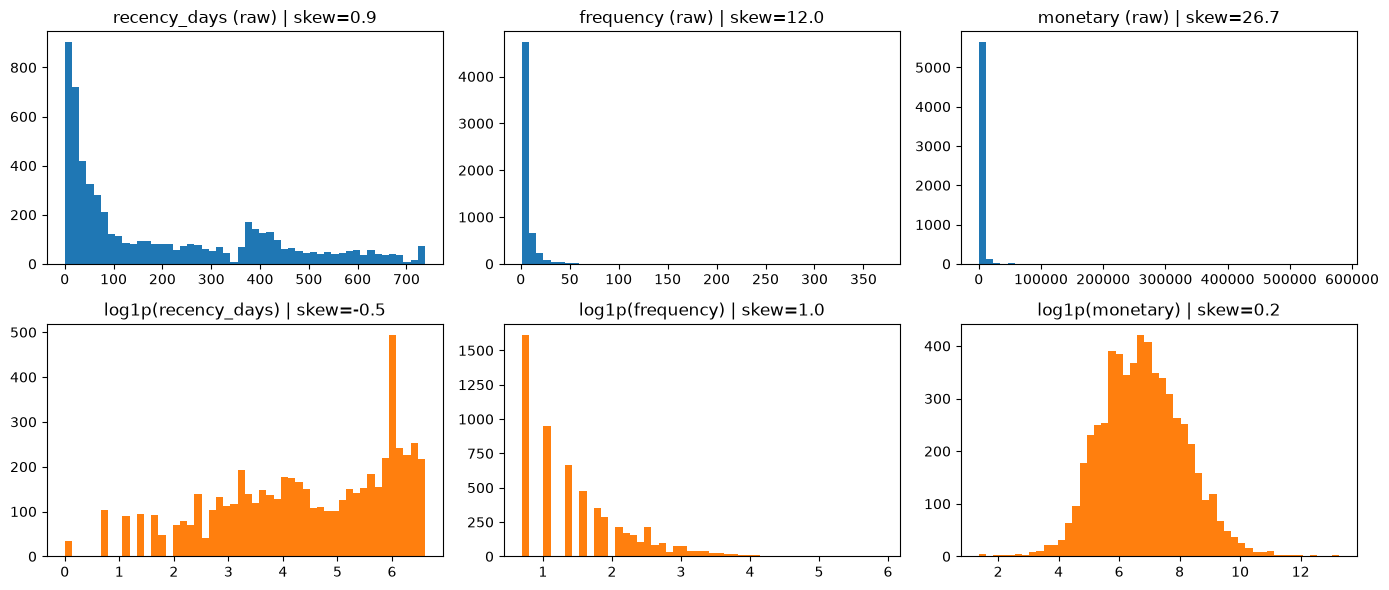

In [6]:
# 2.6 Skew check: raw vs log - why we log-transform before K-Means
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, col in enumerate(["recency_days", "frequency", "monetary"]):
    axes[0, i].hist(profiles[col], bins=50)
    axes[0, i].set_title(f"{col} (raw) | skew={profiles[col].skew():.1f}")
    logged = np.log1p(profiles[col])
    axes[1, i].hist(logged, bins=50, color="tab:orange")
    axes[1, i].set_title(f"log1p({col}) | skew={logged.skew():.1f}")
plt.tight_layout(); plt.show()

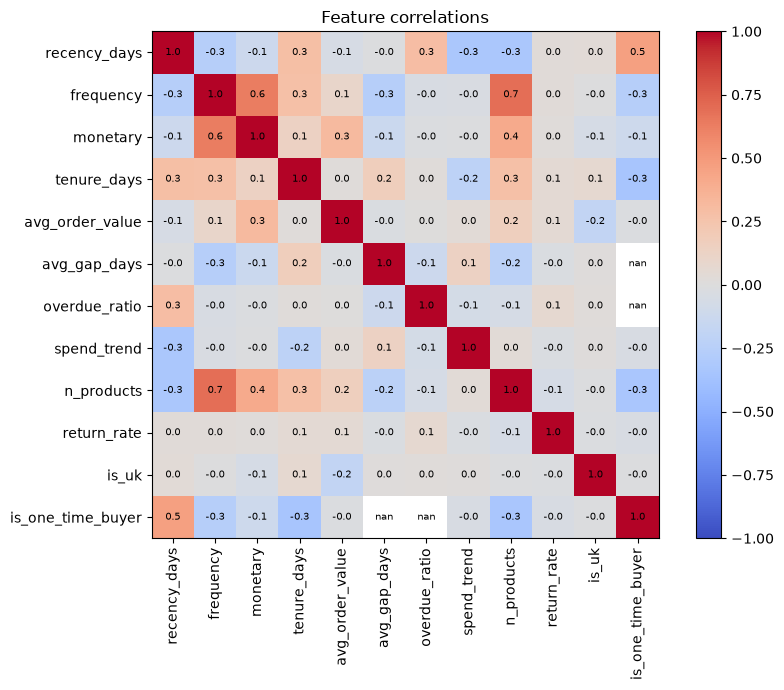

In [7]:
# 2.7 Feature correlations - spot features that say the same thing
corr = profiles[FEATURE_COLS].corr()
plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=90); plt.yticks(range(len(corr)), corr.columns)
for (r, c), v in np.ndenumerate(corr.values):
    plt.text(c, r, f"{v:.1f}", ha="center", va="center", fontsize=7)
plt.colorbar(); plt.title("Feature correlations"); plt.tight_layout(); plt.show()

In [8]:
# 2.8 Save
profiles.to_parquet(PROC / "customers_current.parquet")
print("saved customers_current.parquet:", profiles.shape)

saved customers_current.parquet: (5839, 20)
